In [1]:
%load_ext autoreload
%matplotlib inline
%autoreload 2
import numpy as np
import getdist
from getdist import plots, MCSamples
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import sys
sys.path.append("../../")
from cosmosis.postprocessing.inputs import read_input as _cosmosis_read

In [2]:
names_both = ['7', '8', '1', '2', '3', '4', '5', '6']
labels_both = [r'$\ln \lambda_0$', r'$\mu_z$', r'$\mu_m$', r'$\sigma_{\ln \lambda, 0}$', r'$\sigma_m$', r'$\sigma_z$', r'$\Omega_8$', r'$\sigma_8$']

names_mor = ['1', '2', '3', '4', '5', '6']
labels_mor = [r'$\ln \lambda_0$', r'$\mu_z$', r'$\mu_m$', r'$\sigma_{\ln \lambda, 0}$', r'$\sigma_m$', r'$\sigma_z$']


settings={'mult_bias_correction_order':0,'smooth_scale_2D':4, 'smooth_scale_1D':4, 'boundary_correction_order':0}

In [3]:
from cosmosis.postprocessing.inputs import read_input
def load_cosmosis_chain(
    path: str,
    param_names: list[str],
    burn_fraction: float,
    skip_cosmo = False,
    only_cosmo = False,
    label= None
) -> MCSamples:

    raw   = read_input(path)
    rows  = raw[1]["data"][1][0]
    n_par = len(param_names)
    if skip_cosmo: 
        array = np.array([[row[i] for i in range(2, n_par)] for row in rows])
        param_names = param_names[2:]
    elif only_cosmo:
        array = np.array([[row[i] for i in range(0, 2)] for row in rows])
        param_names = param_names[:2]
    else:
        array = np.array([[row[i] for i in range(n_par)] for row in rows])        
    samples = MCSamples(
        samples  = array,
        names    = param_names,
        labels   = param_names,
        settings = settings,
        label=label
    )
    samples.removeBurn(burn_fraction)
    return samples

## Baseline

In [4]:
path_baseline_both = "./baseline/cosmodc2_redmapper_full_analysis/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt"

baseline_both = load_cosmosis_chain(path_baseline_both, names_both, 0.3, label = "Baseline Counts+Lensing", only_cosmo=True)



LOADING CHAIN FROM FILE:  ./baseline/cosmodc2_redmapper_full_analysis/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt
Removed no burn in


## HMF

In [5]:
tinker08_both_path = "./hmf_analysis/tinker08/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt"
tinker10_both_path = "./hmf_analysis/tinker10/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt"
bocquet16_both_path = "./hmf_analysis/bocquet16/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt"

tinker08_both = load_cosmosis_chain(tinker08_both_path, names_both, 0.3, label = "Tinker08", only_cosmo=True)
tinker10_both = load_cosmosis_chain(tinker10_both_path, names_both, 0.3, label = "Tinker10", only_cosmo=True)
bocquet16_both = load_cosmosis_chain(bocquet16_both_path, names_both, 0.3, label = "Bocquet16", only_cosmo=True)



LOADING CHAIN FROM FILE:  ./hmf_analysis/tinker08/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt
Removed no burn in
LOADING CHAIN FROM FILE:  ./hmf_analysis/tinker10/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt
Removed no burn in
LOADING CHAIN FROM FILE:  ./hmf_analysis/bocquet16/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt
Removed no burn in


## Delta SIgma

In [6]:
cosmo022_both_path = "./deltasigma_cosmology_analysis/cosmo_0.22_0.7/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt"
cosmo03_both_path = "./deltasigma_cosmology_analysis/cosmo_0.3_0.9/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt"
cosmo04_both_path = "./deltasigma_cosmology_analysis/cosmo_0.4_0.8/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt"

cosmo22_both = load_cosmosis_chain(cosmo022_both_path, names_both, 0.3, label = f'$\Omega_c = 022$, $\sigma_8 = 0.7$', only_cosmo=True)
cosmo03_both = load_cosmosis_chain(cosmo03_both_path, names_both, 0.3, label = f'$\Omega_c = 03$, $\sigma_8 = 0.9$', only_cosmo=True)
cosmo04_both = load_cosmosis_chain(cosmo04_both_path, names_both, 0.3, label = f'$\Omega_c = 04$, $\sigma_8 = 0.8$', only_cosmo=True)




LOADING CHAIN FROM FILE:  ./deltasigma_cosmology_analysis/cosmo_0.22_0.7/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt
Removed no burn in
LOADING CHAIN FROM FILE:  ./deltasigma_cosmology_analysis/cosmo_0.3_0.9/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt
Removed no burn in
LOADING CHAIN FROM FILE:  ./deltasigma_cosmology_analysis/cosmo_0.4_0.8/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt
Removed no burn in


## Selection

In [7]:
nofirstbin_both_path = "./high_completeness_analysis/exclude_first_rich_bin/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt"

nofirstbin_both = load_cosmosis_chain(nofirstbin_both_path, names_both, 0.3, label = "No selection, No First Rich Bin", only_cosmo=True)




LOADING CHAIN FROM FILE:  ./high_completeness_analysis/exclude_first_rich_bin/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt
Removed no burn in


## Payerne25 baseline

In [8]:
n_cut=19000
t = np.load(f'./payerne25chains/WLxN/MCMC_fit_m-r_WLxN_1-halo=nfw+c-M=Duffy08_rmin=1.0-rmax=3.5_photoz=Truez_low_z_sample_hmf=Despali16.pkl', allow_pickle = True)


chains = t['flat_chains'].copy()

chains[:, [1, 2]] = chains[:, [2, 1]]

chains[:, [4, 5]] = chains[:, [5, 4]]

# Scale columns 2 and 4 by 1/ln(10)
factor = 1 / np.log(10)
chains[:, [1, 4]] *= factor

WLxNbaselinelowz = MCSamples(samples=chains[n_cut:],names = names_mor, 
                    labels = labels_mor, 
                     settings=settings, 
                     label='Payerne25 Counts+Lensing')

Removed no burn in


## Counts Baseline

In [9]:
path_counts_baseline_both = "./baseline/cosmodc2_redmapper_counts//run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt"

baseline_counts_both = load_cosmosis_chain(path_counts_baseline_both, names_both, 0.3,  label = "Baseline Counts", only_cosmo=True)



LOADING CHAIN FROM FILE:  ./baseline/cosmodc2_redmapper_counts//run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt
Removed no burn in


## Lensing Baseline

In [10]:
path_lensing_baseline_both = "./baseline/cosmodc2_redmapper_lensing/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt"


baseline_lensing_both = load_cosmosis_chain(path_lensing_baseline_both, names_both, 0.3,  label = "Baseline Lensing", only_cosmo=True)


LOADING CHAIN FROM FILE:  ./baseline/cosmodc2_redmapper_lensing/run_in2p3_both/outputs_both/output_rp/number_counts_samples.txt
Removed no burn in


In [11]:
list_chain_baseline = [baseline_both, baseline_counts_both, baseline_lensing_both]
likelihood_baseline = ["Counts+Lensing", "Counts", "Lensing"]
list_chains_hmf = [tinker08_both, tinker10_both, bocquet16_both]
likelihood_hmf = ['tinker08_cosmo', 'tinker10_cosmo','bocquet16_cosmo']
list_chains_sel = [nofirstbin_both]
likelihood_sel = ['nofirstbin_cosmo']
list_chains_ds = [cosmo22_both, cosmo03_both, cosmo04_both]
likelihood_ds = [f'$\Omega_c 022, \sigma_8 0.7$', f'$\Omega_c 03, \sigma_8 0.9$', f'$\Omega_c 04, \sigma_8 0.8$']

sections = [list_chain_baseline, list_chains_hmf, list_chains_sel, list_chains_ds]
color_section = ['C0', 'C1', 'C2', 'C3']
baseline_per_section = [baseline_both, baseline_both, baseline_both,baseline_both]

sections_name = ['Baseline', 'HMF', 'High Completeness', f'Fiducial Cosmo']


truth = {'7': 0.22,
 '8': 0.8}




Baseline Counts+Lensing [0.27369904 0.77443513] [0.04031363 0.04343485]
Baseline Counts [0.24712487 0.79465489] [0.05413561 0.05198826]
Baseline Lensing [0.23992767 0.80423577] [0.05620655 0.05446621]
Tinker08 [0.27281495 0.77398735] [0.03947088 0.04556977]
Tinker10 [0.25721597 0.76957094] [0.03782669 0.04135335]
Bocquet16 [0.2624752  0.76574495] [0.0388126  0.04164513]
No selection, No First Rich Bin [0.27793198 0.77888792] [0.04616    0.05187082]
$\Omega_c = 022$, $\sigma_8 = 0.7$ [0.28464215 0.76076061] [0.03745233 0.0353876 ]
$\Omega_c = 03$, $\sigma_8 = 0.9$ [0.27218726 0.79511955] [0.05261352 0.05362804]
$\Omega_c = 04$, $\sigma_8 = 0.8$ [0.28727287 0.77107569] [0.04681893 0.04425621]


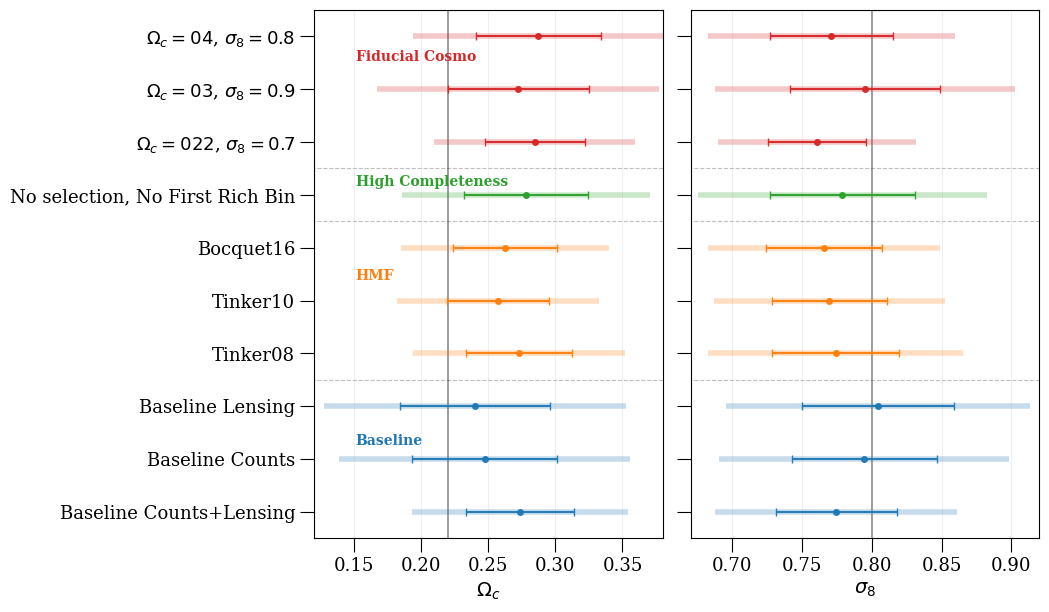

In [18]:
%matplotlib inline
from matplotlib.ticker import FormatStrFormatter
import numpy as np
import matplotlib.pyplot as plt

params_cosmo = ['7', '8']
truth = {'7': 0.22, '8': 0.80}
xlabels = {
    '7': r'$\Omega_c$',
    '8': r'$\sigma_8$',
}

number_of_params = 2

fig, ax = plt.subplots(
    1,
    number_of_params,
    figsize=(10, 7),
    sharey=True,
)

plt.subplots_adjust(wspace=0.08)

y = 0
yticks = []
yticklabels = []

for l, section in enumerate(sections):
    color = color_section[l]
    section_start = y

    for mcmc in section:
        means = mcmc.mean(params_cosmo)
        errors = np.diagonal(mcmc.cov(params_cosmo))**0.5

        print(mcmc.label, means, errors)

        yticks.append(y)
        yticklabels.append(mcmc.label)

        for j, par in enumerate(params_cosmo):

            # 2 sigma: light, wide, behind
            ax[j].errorbar(
                means[j],
                y,
                xerr=2.0 * errors[j],
                marker='none',
                color=color,
                alpha=0.25,
                lw=4.0,
                capsize=0,
                zorder=1,
            )

            # 1 sigma: darker, thinner, on top
            ax[j].errorbar(
                means[j],
                y,
                xerr=errors[j],
                marker='o',
                color=color,
                alpha=0.95,
                lw=1.5,
                capsize=3,
                markersize=4,
                zorder=2,
            )

        y += 1

    section_end = y - 1

    # group separator
    for j in range(number_of_params):
        ax[j].hlines(
            y - 0.5,
            -10,
            10,
            ls='--',
            color='0.75',
            lw=0.8,
            zorder=0,
        )
    y_section = 0.52 * (section_start + section_end)
    
    if len(section) > 1:
        y_section += 0.3
    # section label
    ax[0].text(
        0.151,
        y_section,
        sections_name[l],
        ha='left',
        va='center',
        color=color,
        fontweight='bold',
        fontsize=10,
    )


# Fiducial vertical lines
for j, par in enumerate(params_cosmo):
    ax[j].axvline(
        truth[par],
        color='k',
        lw=1.2,
        alpha=0.45,
        zorder=0,
    )

    ax[j].set_xlabel(xlabels[par], fontsize=14)
    ax[j].tick_params(axis='both', which='both', labelsize=13)
    ax[j].grid(axis='x', alpha=0.2)

ax[0].set_yticks(yticks)
ax[0].set_yticklabels(yticklabels, fontsize=13)

ax[0].xaxis.set_major_formatter(FormatStrFormatter('%.2f'))

ax[0].set_xlim(0.12, 0.38)
ax[1].set_xlim(0.67, 0.92)

ax[0].set_ylim(-0.5, y - 0.5)
plt.savefig("./figures/summary_cosmo.pdf", bbox_inches='tight', dpi=150)

plt.show()

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Tension metrics: fiducial recovery and baseline shifts
# ============================================================

params_cosmo = ['7', '8']

param_latex = {
    '7': r'$\Omega_c$',
    '8': r'$\sigma_8$',
}

truth = {
    '7': 0.22,
    '8': 0.80,
}

# Use zero if fiducials are exact simulation/input values.
# If later you have uncertainties on the fiducial values, replace these.
truth_err = {
    '7': 0.0,
    '8': 0.0,
}


def mean_and_error(chain, params):
    mean = chain.mean(params)
    err = np.sqrt(np.diag(chain.cov(params)))
    return mean, err


def tension_wrt_fiducial(chain, params, truth, truth_err=None):
    mean, err = mean_and_error(chain, params)

    fid = np.array([truth[p] for p in params], dtype=float)

    if truth_err is None:
        fid_err = np.zeros_like(fid)
    else:
        fid_err = np.array([truth_err[p] for p in params], dtype=float)

    t_fid = (mean - fid) / np.sqrt(err**2 + fid_err**2)

    return t_fid


def tension_wrt_baseline(chain, baseline_chain, params):
    mean, err = mean_and_error(chain, params)
    base_mean, base_err = mean_and_error(baseline_chain, params)

    t_base = (mean - base_mean) / np.sqrt(err**2 + base_err**2)

    return t_base


# ============================================================
# Build table
# ============================================================

rows = []

for section_name, section, baseline_chain in zip(
    sections_name,
    sections,
    baseline_per_section,
):
    for chain in section:
        mean, err = mean_and_error(chain, params_cosmo)
        t_fid = tension_wrt_fiducial(chain, params_cosmo, truth, truth_err)
        t_base = tension_wrt_baseline(chain, baseline_chain, params_cosmo)

        for i, p in enumerate(params_cosmo):
            rows.append({
                "section": section_name,
                "chain": chain.label,
                "param": p,
                "param_label": param_latex[p],
                "mean": mean[i],
                "sigma": err[i],
                "fiducial": truth[p],
                "T_fid": t_fid[i],
                "abs_T_fid": abs(t_fid[i]),
                "T_base": t_base[i],
                "abs_T_base": abs(t_base[i]),
            })

df_tension = pd.DataFrame(rows)

df_tension

,section,chain,param,param_label,mean,sigma,fiducial,T_fid,abs_T_fid,T_base,abs_T_base
0,Baseline,Baseline Counts+Lensing,7,$\Omega_c$,0.273699,0.040314,0.22,1.332032,1.332032,0.000000,0.000000
1,Baseline,Baseline Counts+Lensing,8,$\sigma_8$,0.774435,0.043435,0.80,-0.588580,0.588580,0.000000,0.000000
2,Baseline,Baseline Counts,7,$\Omega_c$,0.247125,0.054136,0.22,0.501054,0.501054,-0.393709,0.393709
3,Baseline,Baseline Counts,8,$\sigma_8$,0.794655,0.051988,0.80,-0.102814,0.102814,0.298469,0.298469
4,Baseline,Baseline Lensing,7,$\Omega_c$,0.239928,0.056207,0.22,0.354544,0.354544,-0.488244,0.488244
5,Baseline,Baseline Lensing,8,$\sigma_8$,0.804236,0.054466,0.80,0.077769,0.077769,0.427773,0.427773
6,HMF,Tinker08,7,$\Omega_c$,0.272815,0.039471,0.22,1.338074,1.338074,-0.015670,0.015670
7,HMF,Tinker08,8,$\sigma_8$,0.773987,0.045570,0.80,-0.570831,0.570831,-0.007113,0.007113
8,HMF,Tinker10,7,$\Omega_c$,0.257216,0.037827,0.22,0.983855,0.983855,-0.298166,0.298166
9,HMF,Tinker10,8,$\sigma_8$,0.769571,0.041353,0.80,-0.735830,0.735830,-0.081107,0.081107


In [14]:
# ============================================================
# Compact summary for paper text
# ============================================================

# Main baseline recovery relative to fiducial
# Use the combined Counts+Lensing baseline as the reference.
main_baseline = baseline_both

T_main_fid = tension_wrt_fiducial(
    main_baseline,
    params_cosmo,
    truth,
    truth_err,
)

print("Main baseline recovery:")
for p, t in zip(params_cosmo, T_main_fid):
    print(f"{param_latex[p]:12s}: T_fid = {t:+.2f} sigma")

print()
print(f"Max baseline |T_fid| = {np.max(np.abs(T_main_fid)):.2f} sigma")


# Robustness tests: exclude the first section if you only want non-baseline tests
df_nonbaseline_tests = df_tension[df_tension["section"] != "Baseline"].copy()

max_shift_base = df_nonbaseline_tests["abs_T_base"].max()
max_shift_fid = df_nonbaseline_tests["abs_T_fid"].max()

print()
print("Robustness tests:")
print(f"Max |T_base| = {max_shift_base:.2f} sigma")
print(f"Max |T_fid|  = {max_shift_fid:.2f} sigma")


# Find which chain/parameter gives the largest shifts
idx_base = df_nonbaseline_tests["abs_T_base"].idxmax()
idx_fid = df_nonbaseline_tests["abs_T_fid"].idxmax()

print()
print("Largest baseline shift:")
print(df_nonbaseline_tests.loc[idx_base, ["section", "chain", "param_label", "T_base"]])

print()
print("Largest fiducial offset:")
print(df_nonbaseline_tests.loc[idx_fid, ["section", "chain", "param_label", "T_fid"]])

Main baseline recovery:
$\Omega_c$  : T_fid = +1.33 sigma
$\sigma_8$  : T_fid = -0.59 sigma

Max baseline |T_fid| = 1.33 sigma

Robustness tests:
Max |T_base| = 0.30 sigma
Max |T_fid|  = 1.73 sigma

Largest baseline shift:
section                           Fiducial Cosmo
chain          $\Omega_c = 03$, $\sigma_8 = 0.9$
param_label                           $\sigma_8$
T_base                                  0.299725
Name: 17, dtype: object

Largest fiducial offset:
section                            Fiducial Cosmo
chain          $\Omega_c = 022$, $\sigma_8 = 0.7$
param_label                            $\Omega_c$
T_fid                                    1.725985
Name: 14, dtype: object


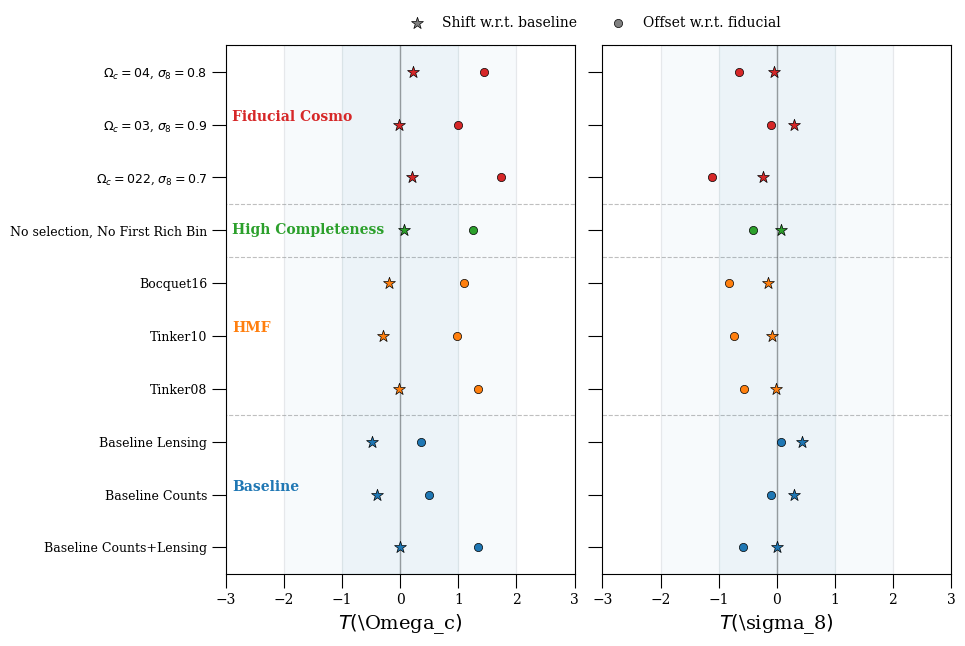

In [15]:
# ============================================================
# Plot: T_fid and T_base for each chain
# ============================================================

fig, ax = plt.subplots(
    1,
    len(params_cosmo),
    figsize=(10, 7),
    sharey=True,
)

plt.subplots_adjust(wspace=0.08)

y = 0
yticks = []
yticklabels = []

for l, (section_name, section, baseline_chain) in enumerate(
    zip(sections_name, sections, baseline_per_section)
):
    color = color_section[l]
    section_start = y

    for chain in section:
        t_fid = tension_wrt_fiducial(chain, params_cosmo, truth, truth_err)
        t_base = tension_wrt_baseline(chain, baseline_chain, params_cosmo)

        yticks.append(y)
        yticklabels.append(chain.label)

        for j, p in enumerate(params_cosmo):
            ax[j].scatter(
                t_base[j],
                y,
                marker="*",
                s=80,
                color=color,
                edgecolors="k",
                linewidths=0.5,
                zorder=3,
            )

            ax[j].scatter(
                t_fid[j],
                y,
                marker="o",
                s=35,
                color=color,
                edgecolors="k",
                linewidths=0.5,
                zorder=3,
            )

        y += 1

    section_end = y - 1

    for j in range(len(params_cosmo)):
        ax[j].hlines(
            y - 0.5,
            -10,
            10,
            ls="--",
            color="0.75",
            lw=0.8,
            zorder=0,
        )

    # section label: midpoint, with small offset only for multi-row sections
    y_section = 0.5 * (section_start + section_end)
    if len(section) > 1:
        y_section += 0.15

    ax[0].text(
        -2.9,
        y_section,
        section_name,
        ha="left",
        va="center",
        color=color,
        fontweight="bold",
        fontsize=10,
    )


for j, p in enumerate(params_cosmo):
    ax[j].axvline(0.0, color="k", lw=1.0, alpha=0.4, zorder=0)

    ax[j].axvspan(-1, 1, color="C0", alpha=0.05, zorder=0)
    ax[j].axvspan(-2, 2, color="C0", alpha=0.03, zorder=0)

    ax[j].set_xlim(-3, 3)
    ax[j].set_xlabel(rf"$T({param_latex[p]})$", fontsize=14)
    ax[j].grid(axis="x", alpha=0.2)
    ax[j].tick_params(axis="both", which="both", labelsize=10)

ax[0].set_yticks(yticks)
ax[0].set_yticklabels(yticklabels, fontsize=9)
ax[0].set_ylim(-0.5, y - 0.5)

# Dummy points for legend
ax[0].scatter(
    [],
    [],
    marker="*",
    s=80,
    color="0.5",
    edgecolors="k",
    linewidths=0.5,
    label=r"Shift w.r.t. baseline",
)

ax[0].scatter(
    [],
    [],
    marker="o",
    s=35,
    color="0.5",
    edgecolors="k",
    linewidths=0.5,
    label=r"Offset w.r.t. fiducial",
)

ax[0].legend(
    loc="upper center",
    bbox_to_anchor=(1.05, 1.08),
    ncol=2,
    frameon=False,
    fontsize=10,
)
plt.savefig("./figures/summary_tension_cosmo.pdf", bbox_inches='tight', dpi=150)
plt.show()